In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
transform=transforms.Compose([
    transforms.Resize(299),    
    transforms.ToTensor() 
])

aug_trans = transforms.Compose([
    transforms.Resize((128,128)), 
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

In [3]:
seed = 124

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

In [4]:
DATA_DIR = r'/home/pcdm/Desktop/emotion/train'
model_algo="inception_v3"


In [5]:
#建立dataset class
class ImageDataset(Dataset):
    def __init__(self, root,trans,decision_mode=False):
        super().__init__()
        self.images = ImageFolder(root=root)        
        self.classes = self.images.class_to_idx.items()
        self.flag= [True] * len(self.images)
        self.decision_mode=decision_mode
        self.transform = trans

        # self.aug_trans = trans2
        # self.sum=0
    def __len__(self):
        return len(self.images)
   
    def __getitem__(self,idx):
        image, label=self.images[idx]

        # if(self.flag[idx]==True):
        image=self.transform(image)
        # else:
        #     image=self.aug_trans(image)
        #     self.sum+=1

        if(self.decision_mode==True):
            label=int(self.flag[idx])
            
        return image,label,idx
    
    def update_flag(self, idx):
        self.flag[idx] = False
    

In [6]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

# generator = torch.Generator()
# generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)
test_size = int(0.1 * size)
train_size = int(size - valid_size - test_size)

trainset, validset, testset = random_split(images, (train_size, valid_size, test_size))


In [7]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()
idx2class = {v: k for k, v in trainset.dataset.classes}

In [8]:
#建立模型框架
def model_create(model_algo,data_name):
    model = getattr(models,model_algo)(weights=True)

    # if(data_name=='decision'):
    #     class_number=2
    # else:
    class_number=len(trainset.dataset.classes)
    

    if(model_algo=='googlenet' or model_algo=='resnet18' ):
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, class_number)
        
    elif model_algo == 'inception_v3':
        # 修改輔助分類器
        num_ftrs_aux = model.AuxLogits.fc.in_features
        model.AuxLogits.fc = nn.Linear(num_ftrs_aux, class_number)

        # 修改最後的全連接層
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, class_number)
    else :
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_ftrs,class_number)

    return model

In [9]:
#模型表現
def evaluate_model(model,data_dl,size):
        model.to(device)
        ######################    
        # validate the model #
        ######################
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
                model.eval()   

                for data, target,idx in data_dl:

                        data,target=data.to(device),target.to(device)
                        out= model(data)
                        _, y_pred_tag = torch.max(out, dim = 1)
                        loss = criterion(out, target)
                        
                        flat_true.extend(target.cpu().numpy())
                        flat_pred.extend(y_pred_tag.cpu().numpy())

                        total_loss+= loss.item()*data.size(0)
                        correct=torch.sum(y_pred_tag == target).item()
                        accu += correct      

                total_loss=total_loss/size
                accu=accu/size
        confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
        return total_loss,accu,confusion_matrix_valid

In [10]:
    
def evaluate_model_TF(model,TorF):
    num=0
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
   
    with torch.no_grad():
            model_0.eval()   
            for data, target,idx in valid_dl:

                    data,target=data.to(device),target.to(device)
                    out_growth= model_0(data)
                    _, decision_tag = torch.max(out_growth, dim = 1)

                    for result,d,t in zip(torch.eq(target,decision_tag),data,target):
                            if (TorF == "T" and result.cpu().numpy()) or (TorF == "F" and not result.cpu().numpy()):
                                out = model(d.unsqueeze(0))
                                _, y_pred_tag = torch.max(out, dim = 1)
                                loss=criterion(out,t.unsqueeze(0))
                                num+=1
                        
                                total_loss+= loss.item()
                                correct=torch.sum(y_pred_tag == t).item()
                
                                accu += correct 
                                flat_true.extend(t.unsqueeze(0).cpu().numpy())
                                flat_pred.extend(y_pred_tag.cpu().numpy()) 

    valid_loss=total_loss/num
    valid_accu=accu/num                                  
    print(f"Model_{TorF} valid loss={valid_loss}, accu={valid_accu},sample_number={num}") 
    confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return valid_loss,valid_accu,confusion_matrix_valid

In [11]:

def evaluate_model_decision(model):
        correct=0
        flat_true=[]
        flat_pred=[]
        decision_valid_accu=0
        with torch.no_grad():
                model_0.eval()   
                for data, target,idx in valid_dl:

                        data,target=data.to(device),target.to(device)
                        out_growth= model_0(data)   #原始model
                        _, y_pred_tag = torch.max(out_growth, dim = 1)

                        out_predict= model(data)  #預測要用哪個model
                        _, predict = torch.max(out_predict, dim = 1)
        
                        for pred,result in zip(predict,torch.eq(target,y_pred_tag)):
                                if(result==pred):
                                        correct+=1
                                flat_true.append(result.cpu().numpy())
                                flat_pred.append(pred.cpu().numpy())

        decision_valid_accu=correct/valid_size

        print("decision_valid accu=",decision_valid_accu) 
        confusion_matrix_decision_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
        return  decision_valid_accu,confusion_matrix_decision_valid

In [12]:
#訓練模型
def trainer(epochs,model,criterion,optim,data_dl,data_name):
        train_accus=[]
        val_accus=[]
        best_val_accu = 0.0
        epochs_without_improvement = 0
        overfitting = 0
        patience=3
        best_model = None

        for epoch in range(epochs):
                
                train_loss=0
                model.to(device)
                model.train()
                ###################
                # train the model #
                ###################
                for data, target,idx in data_dl:
                        
                        optim.zero_grad()
                        data,target=data.to(device),target.to(device)  #將data、target放到gpu上
                      
                        out,_ = model(data)
                        # _, y_pred_tag = torch.max(out, dim = 1)  
                        
                        loss = criterion(out, target)
                        
                        loss.backward()
                        optim.step()
                        # print(target)
                
                      
                train_loss,train_accu,_=evaluate_model(model,data_dl,len(data_dl.dataset))
                print(f"Epoch={epoch},train_loss={train_loss},train_accu={train_accu}")
                train_accus.append(train_accu)
                
                if(data_name=="T" or data_name=="F"):  
                        
                        val_loss,val_accu,_=evaluate_model_TF(model,data_name)
                # elif(data_name=="decision"):
                #         val_accu,_=evaluate_model_decision(model)
                else:
                        val_loss,val_accu,_=evaluate_model(model,valid_dl,valid_size)
                        print(f"Epoch={epoch},valid_loss={val_loss},valid_accu={val_accu}")

                val_accus.append(val_accu)
        
                # Early stopping
                if val_accu > best_val_accu:
                        best_val_accu = val_accu
                        epochs_without_improvement = 0
                        best_model=copy.deepcopy(model)
                        print(f"{epochs_without_improvement}")
                        
                # elif (train_accu-best_val_accu>0.02):
                #         overfitting += 1
                        
                else:
                        epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                        print(f"{epochs_without_improvement} Early stopping!")
                        break
                # elif overfitting >= patience:
                #         print("Early stopping overfit!")
                #         break
                
                torch.save(best_model, f"model_{model_algo}_{data_name}_{epoch}.pth")               
        plt.plot(train_accus,'-o')
        plt.plot(val_accus,'-o')

        plt.xlabel('epoch')
        plt.ylabel('Accuracy')
        plt.legend(['Train','Valid'])
        plt.show()
        torch.save(best_model, f"model_{model_algo}_{data_name}.pth")  
        return best_model
                

In [13]:
#將模型建立框架後並訓練
def model_train(model_algo,data_dl,data_name,epochs,class_weight=None):
    
    model=model_create(model_algo,data_name)
    if(data_name=="F"):
        # trainset.dataset.decision_mode=True
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss(weight=class_weight)
        
        model=trainer(epochs,model,criterion,optim,data_dl,data_name)
        # trainset.dataset.decision_mode=False
    else:
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,data_dl,data_name)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model

In [14]:
# model_0 = torch.load(f'model_{model_algo}_0_14.pth')

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.8062147527657936,train_accu=0.7076136691537162
Epoch=0,valid_loss=0.990979894139894,valid_accu=0.6298701298701299
0
Epoch=1,train_loss=0.5469608895984013,train_accu=0.8252195061626613
Epoch=1,valid_loss=0.9122017580709416,valid_accu=0.6688311688311688
0
Epoch=2,train_loss=0.32406588975762274,train_accu=0.894430932849664
Epoch=2,valid_loss=0.9680021495186061,valid_accu=0.6757575757575758
0
Epoch=3,train_loss=0.2213141789754376,train_accu=0.9324374458963683
Epoch=3,valid_loss=1.0600713081002064,valid_accu=0.6658008658008658
Epoch=4,train_loss=0.17643477472204203,train_accu=0.940846696071561
Epoch=4,valid_loss=1.3240423710315259,valid_accu=0.643001443001443
Epoch=5,train_loss=0.12796336423348154,train_accu=0.9603033925553403
Epoch=5,valid_loss=1.3902309009007046,valid_accu=0.6473304473304473
3 Early stopping!


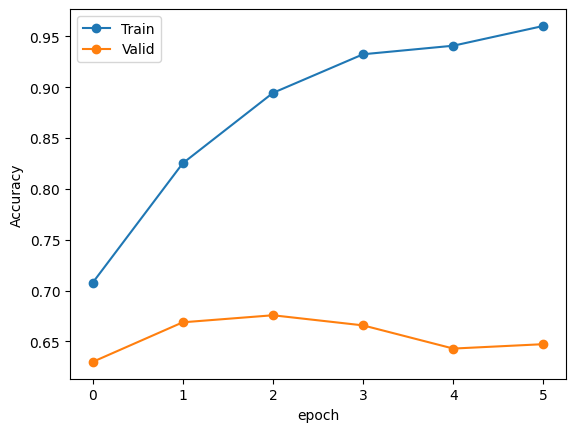

In [15]:
model_0=model_train(model_algo,train_dl,"0",20)
# model_0 = torch.load(f'model_{model_algo}_0_14.pth')

In [16]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size)
train_loss,train_accu

(0.32406588665871683, 0.894430932849664)

In [17]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size)
valid_loss,valid_accu

(0.9680021061009659, 0.6757575757575758)

In [18]:
model_0.eval()

out_F=[]
out_T=[]
with torch.no_grad():

    for (data,target,idx) in valid_dl:
        data,target=data.cuda(),target.cuda()
        out = model_0(data)
        
        _, y_pred_tag = torch.max(out, dim = 1) 

        softmax = torch.softmax(out, dim=1)
        # temperature1 = 0.5       

        # # 對預測概率進行溫度調整

        # softmax = softmax / temperature1
        # softmax= torch.softmax(softmax, dim=0)
        
        
        for idx,t,tag,soft in zip(idx,target,y_pred_tag,softmax):
            sort_soft=sorted(soft,reverse=True)
            if(t!=tag):
                out_F.append((sort_soft[0]-sort_soft[1]).cpu().numpy())
            else:
                out_T.append((sort_soft[0]-sort_soft[1]).cpu().numpy())

In [19]:
def plot_hist(data):
    plt.hist(data, bins=5, edgecolor='black', color='skyblue')

    # Add labels and title
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Histogram')
    for value, freq in zip(plt.hist(data, bins=5, edgecolor='black', color='skyblue')[0], plt.hist(data, bins=5, edgecolor='black', color='skyblue')[1]):
        plt.text(freq + 0.01, value + 0.5, str(int(value)), fontsize=10, color='black')
        
    # Display the histogram
    plt.show()

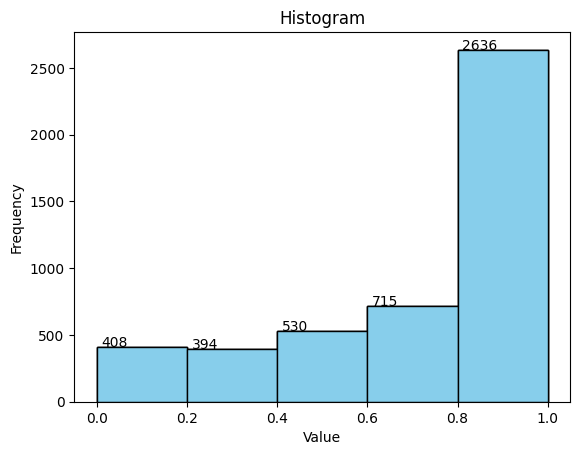

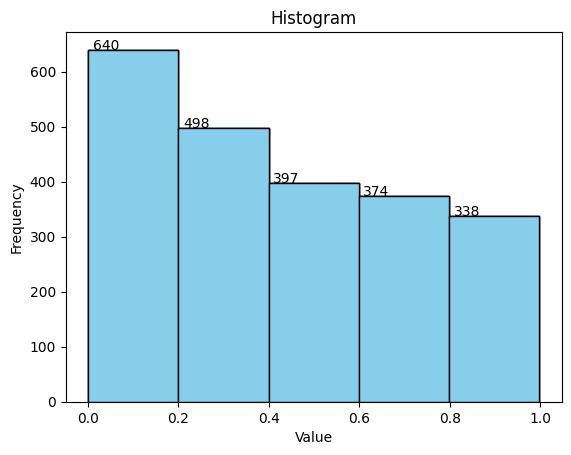

In [20]:
plot_hist(out_T)
plot_hist(out_F)

softmax最大減第二大

In [21]:
sum(out_T)/len(out_T) #平均

0.7293698553846302

In [22]:
sum(out_F)/len(out_F)

0.43106666597250465

In [23]:
out_F=[]
out_T=[]
with torch.no_grad():

    for (data,target,idx) in valid_dl:
        data,target=data.cuda(),target.cuda()
        out = model_0(data)
        
        _, y_pred_tag = torch.max(out, dim = 1) 

        softmax_probs = torch.softmax(out, dim=1)

        for idx,t,tag,prob in zip(idx,target,y_pred_tag,softmax_probs):
            if(t!=tag):
                out_F.append(prob.max().cpu().numpy())
                
            else:
                out_T.append(prob.max().cpu().numpy())
            

softmax.max

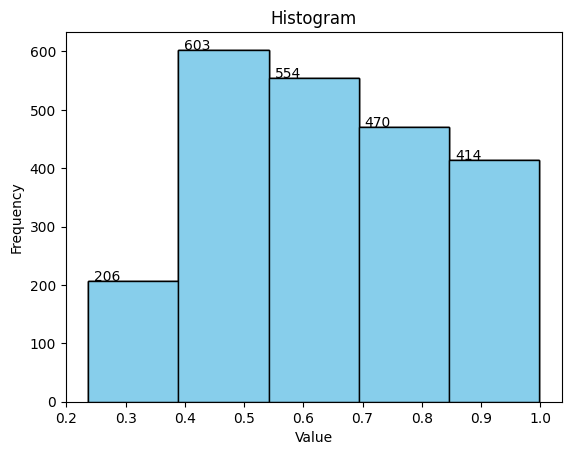

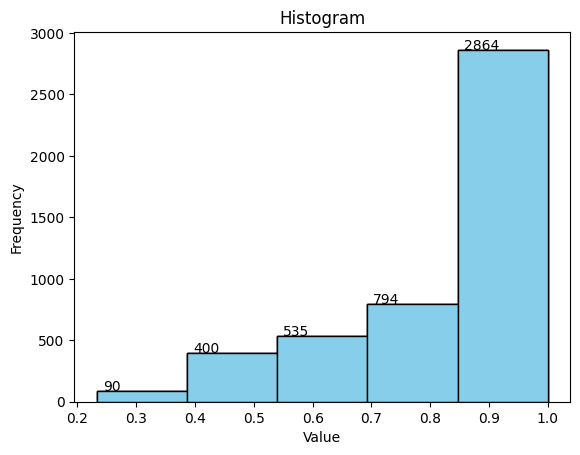

In [24]:
plot_hist(out_F)
plot_hist(out_T)

In [25]:
sum(out_F)/len(out_F)

0.6400278072703081

In [26]:
sum(out_T)/len(out_T)

0.8338445591896028

output Max

In [27]:
out_F=[]
out_T=[]
with torch.no_grad():

    for (data,target,idx) in train_dl:
        data,target=data.cuda(),target.cuda()
        out = model_0(data)
        
        _, y_pred_tag = torch.max(out, dim = 1) 
       
        
        for idx,t,tag,out in zip(idx,target,y_pred_tag,out):
            if(t!=tag):
                out_F.append(out.max().cpu().numpy())
            
            else:
                out_T.append(out.max().cpu().numpy())

print(max(out_F),min(out_F))
print(max(out_T),min(out_T))

8.719084 0.28769246
18.351017 0.3381621


In [28]:
# 將資料切分成true and false
def split_data(model_0,data_dl):
    model_0.eval()

    indexF=[]
    indexT=[]
    with torch.no_grad():

        for (data,target,idx) in train_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            
            _, y_pred_tag = torch.max(out, dim = 1) 

            softmax = torch.softmax(out, dim=1)
            
            
            for idx,t,tag,softmax in zip(idx,target,y_pred_tag,softmax):
                sort_soft=sorted(softmax,reverse=True)
                value=sort_soft[0]-sort_soft[1]

                if(t!=tag):
                    indexF.append(idx.cpu().numpy().item())  
                
                # elif(value>0.8):

                #     indexF.append(idx.cpu().numpy().item())
                #     indexT.append(idx.cpu().numpy().item())

                else:
                    indexT.append(idx.cpu().numpy().item())       
                # if(t!=tag):
                #     indexF.append(idx.cpu().numpy().item())
             
                # elif(value< 10):
                #     indexF.append(idx.cpu().numpy().item())
                #     indexT.append(idx.cpu().numpy().item())
                # else:
                #     indexT.append(idx.cpu().numpy().item())

                
            torch.cuda.empty_cache() 
        return indexF,indexT

In [35]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
indexF,indexT=split_data(model_0,train_dl)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=33)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
# decision_dl = DataLoader(trainset, batch_size=64)

In [30]:
len(indexF),len(indexT)

(2561, 21698)

In [31]:
def evaluate_model_TF(model,TorF):
    num=0
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
   
    with torch.no_grad():
            model_0.eval()   
            for data, target,idx in valid_dl:

                data,target=data.to(device),target.to(device)
                out_growth= model_0(data)
                _, y_pred_tag = torch.max(out_growth, dim = 1)
                
                for result,d,t in zip(torch.eq(target,y_pred_tag),data,target):
                        if (TorF == "T" and result.cpu().numpy()) or (TorF == "F" and not result.cpu().numpy()):
                            out = model(d.unsqueeze(0))
                            _, y_pred_tag = torch.max(out, dim = 1)
                            loss=criterion(out,t.unsqueeze(0))
                            num+=1
                    
                            total_loss+= loss.item()
                            correct=torch.sum(y_pred_tag == t).item()
            
                            accu += correct 
                            flat_true.extend(t.unsqueeze(0).cpu().numpy())
                            flat_pred.extend(y_pred_tag.cpu().numpy())  

    valid_loss=total_loss/num
    valid_accu=accu/num                                  
    print(f"Model_{TorF} valid loss={valid_loss}, accu={valid_accu},sample_number={num}") 
    confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return valid_loss,valid_accu,confusion_matrix_valid

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.5976994043232077,train_accu=0.7966171997419117
Model_T valid loss=0.4878706601875519, accu=0.8443305573350416,sample_number=4683
0
Epoch=1,train_loss=0.36459303277532057,train_accu=0.8820167757396995
Model_T valid loss=0.3931151194205797, accu=0.866965620328849,sample_number=4683
0
Epoch=2,train_loss=0.19042930466830538,train_accu=0.9416996958245
Model_T valid loss=0.3829698063316315, accu=0.8612000854153321,sample_number=4683
Epoch=3,train_loss=0.12195834227059789,train_accu=0.961701539312379
Model_T valid loss=0.39357675240593665, accu=0.8567157804825967,sample_number=4683
Epoch=4,train_loss=0.08036008950177619,train_accu=0.9738685593142226
Model_T valid loss=0.433522213406776, accu=0.8569293188127269,sample_number=4683
3 Early stopping!


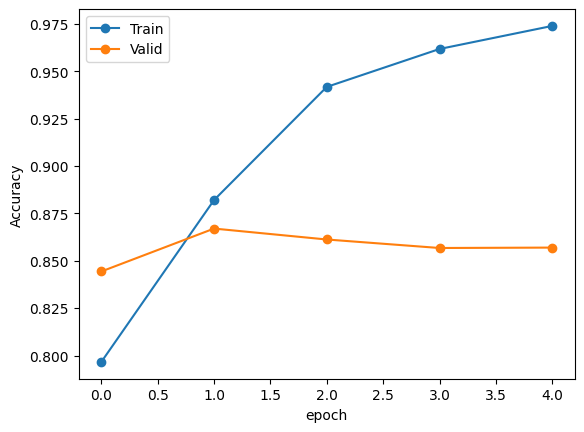

In [32]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,"T",20)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

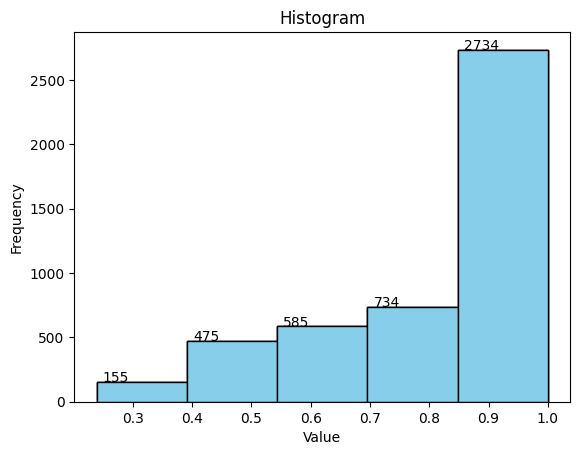

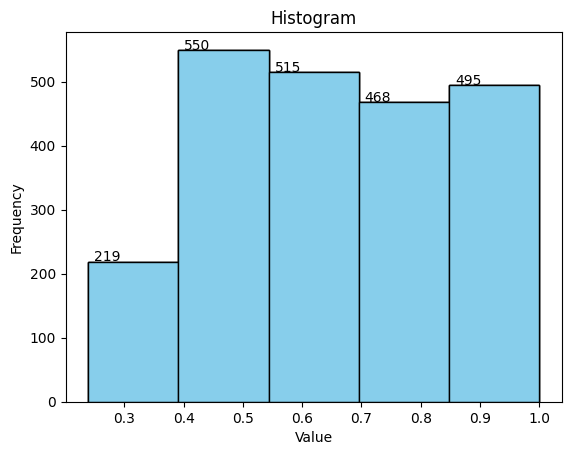

In [33]:
model_0.eval()

out_F=[]
out_T=[]
with torch.no_grad():

    for (data,target,idx) in valid_dl:
        data,target=data.cuda(),target.cuda()
        out = model_0(data)
        
        _, y_pred_tag = torch.max(out, dim = 1) 

        

        for result,d,t in zip(torch.eq(target,y_pred_tag),data,target):
            
            if (result.cpu().numpy()):
            
                out = model_T(d.unsqueeze(0))
                _, y_pred_tag = torch.max(out, dim = 1)
                softmax = torch.softmax(out, dim=1)
                sorted_probs, _ = torch.sort(softmax, descending=True, dim=1)

                # 取出最大和第二大的概率值
                max_prob = sorted_probs[:, 0]
                second_prob = sorted_probs[:, 1]

                # print(max_prob-second_prob)
                # if(y_pred_tag==t):
                out_T.append((max_prob).cpu().numpy().item())
                # else:
                #     out_F.append((max_prob-second_prob).cpu().numpy().item())

            else:
                out = model_T(d.unsqueeze(0))
                _, y_pred_tag = torch.max(out, dim = 1)
                softmax = torch.softmax(out, dim=1)
                sorted_probs, _ = torch.sort(softmax, descending=True, dim=1)

                # 取出最大和第二大的概率值
                max_prob = sorted_probs[:, 0]
                second_prob = sorted_probs[:, 1]

                # print(max_prob-second_prob)
                # if(y_pred_tag==t):
                out_F.append((max_prob).cpu().numpy().item())
plot_hist(out_T)
plot_hist(out_F)

Epoch=0,train_loss=1.3916478965581278,train_accu=0.5224521671222179
Model_F valid loss=1.7273935276930419, accu=0.2866043613707165,sample_number=2247
0
Epoch=1,train_loss=0.8487356135222373,train_accu=0.7590784849668099
Model_F valid loss=1.8235845521646152, accu=0.2857142857142857,sample_number=2247
Epoch=2,train_loss=0.32908064523207775,train_accu=0.9484576337368216
Model_F valid loss=2.1037480100954578, accu=0.28304405874499333,sample_number=2247
Epoch=3,train_loss=0.10747623668051892,train_accu=0.9793049590003905
Model_F valid loss=2.3666576100297165, accu=0.29817534490431685,sample_number=2247
0
Epoch=4,train_loss=0.04475598973838474,train_accu=0.9964857477547833
Model_F valid loss=2.477145648977161, accu=0.3097463284379172,sample_number=2247
0
Epoch=5,train_loss=0.023829257286276287,train_accu=0.9972666926981648
Model_F valid loss=2.7491945315254447, accu=0.2857142857142857,sample_number=2247
Epoch=6,train_loss=0.015703548644354793,train_accu=0.9980476376415462
Model_F valid loss

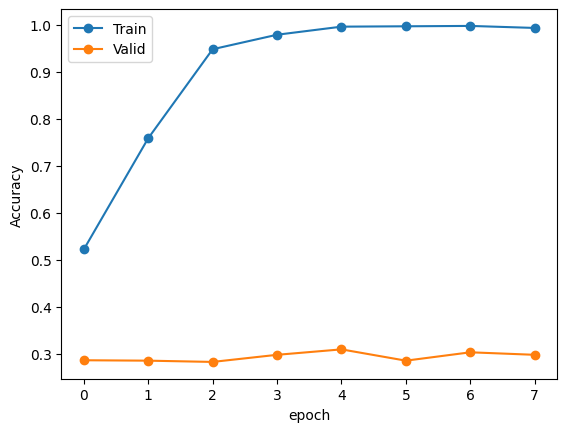

In [36]:
model_F=model_train(model_algo,Fdl,"F",20)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [37]:
model_0.eval()

out_F=[]
out_T=[]
with torch.no_grad():

    for (data,target,idx) in valid_dl:
        data,target=data.cuda(),target.cuda()
        out = model_0(data)
        
        _, y_pred_tag = torch.max(out, dim = 1) 

        for result,d,t in zip(torch.eq(target,y_pred_tag),data,target):
            if (not result.cpu().numpy()):
                out = model_F(d.unsqueeze(0))
                _, y_pred_tag = torch.max(out, dim = 1)
                softmax = torch.softmax(out, dim=1)
                sorted_probs, _ = torch.sort(softmax, descending=True, dim=1)

                # 取出最大和第二大的概率值
                max_prob = sorted_probs[:, 0]
                second_prob = sorted_probs[:, 1]

                # print(max_prob-second_prob)
                if(y_pred_tag==t):
                    out_T.append((max_prob-second_prob).cpu().numpy().item())
                else:
                    out_F.append((max_prob-second_prob).cpu().numpy().item())

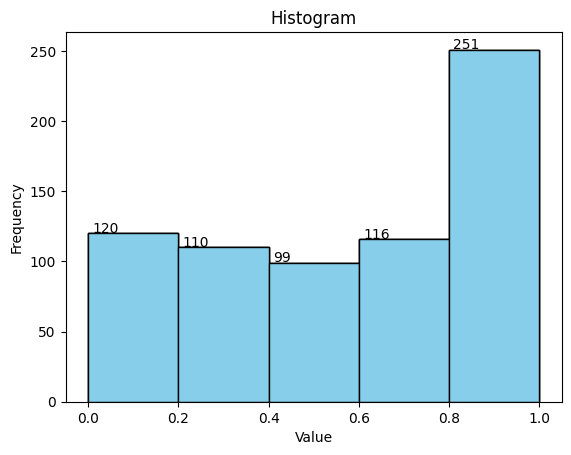

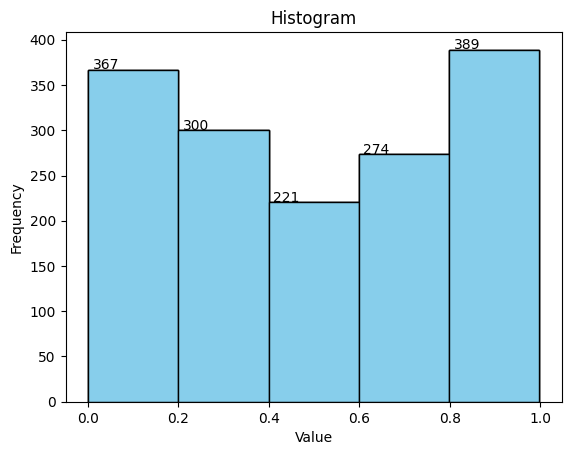

In [38]:
plot_hist(out_T)
plot_hist(out_F)

In [39]:
torch.cuda.empty_cache()

In [40]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset))
T_loss,T_accu

(0.3645930340870183, 0.8820167757396995)

In [41]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset))
F_loss,F_accu

(0.04475598379515754, 0.9964857477547833)

In [42]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model_TF(model_T,"T")
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model_TF(model_F,"F")


Model_T valid loss=0.3931151194205797, accu=0.866965620328849,sample_number=4683
Model_F valid loss=2.477145648977161, accu=0.3097463284379172,sample_number=2247


In [43]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]


    with torch.no_grad():

        for data,target,idx in data_dl:

            outputs=[]
            data,target=data.to(device),target.to(device)

            for d,t in zip(data,target):

                out_0=model_0(d.unsqueeze(0))
                out_f=model_F(d.unsqueeze(0))
                out_t=model_T(d.unsqueeze(0))
                
                softmax_0 = torch.softmax(out_0, dim=1)
                softmax_F = torch.softmax(out_f, dim=1)
                softmax_T = torch.softmax(out_t, dim=1)



                max_softmax = max(softmax_0.max(), softmax_F.max(), softmax_T.max())
                if max_softmax == softmax_0.max():
                    outputs.append(out_0)
                elif max_softmax == softmax_F.max():
                    outputs.append(out_f)
                else:
                    outputs.append(out_t)
                                        
            
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)
        

            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())
            
            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total

In [44]:
total_train_loss,total_train_accu,confusion_matrix_total_train=total_model_evaluate(train_dl,train_size)
total_train_loss,total_train_accu

(0.7064412398813914, 0.8617008120697474)

In [45]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid=total_model_evaluate(valid_dl,valid_size)
total_valid_loss,total_valid_accu

(1.5748072869849927, 0.6251082251082251)

In [46]:
def plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,model_name):
    fig = plt.figure(figsize=(15, 5))
    ax1, ax2 = fig.add_subplot(121), fig.add_subplot(122)

    sns.heatmap(confusion_matrix_train, annot=True, fmt='',cbar=False,ax=ax1,square=True).set(title=f"{model_algo}_{model_name} train confusion matrix", xlabel="Predicted Label", ylabel="True Label")
    sns.heatmap(confusion_matrix_valid, annot=True, fmt='',ax=ax2,square=True).set(title=f"{model_algo}_{model_name} valid confusion matrix", xlabel="Predicted Label", ylabel="True Label")


In [47]:
train_losses=[train_loss,T_loss,F_loss,total_train_loss]
train_accuracies=[train_accu,T_accu,F_accu,total_train_accu]
valid_losses=[valid_loss,T_valid_loss,F_valid_loss,total_valid_loss]
valid_accuracies=[valid_accu,T_valid_accu,F_valid_accu,total_valid_accu]

In [48]:
model_algos=['Model_0',"Model_T","Model_F","Total_Model"]
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.324066,0.894431,0.968002,0.675758
1,Model_T,0.364593,0.882017,0.393115,0.866966
2,Model_F,0.044756,0.996486,2.477146,0.309746
3,Total_Model,0.706441,0.861701,1.574807,0.625108


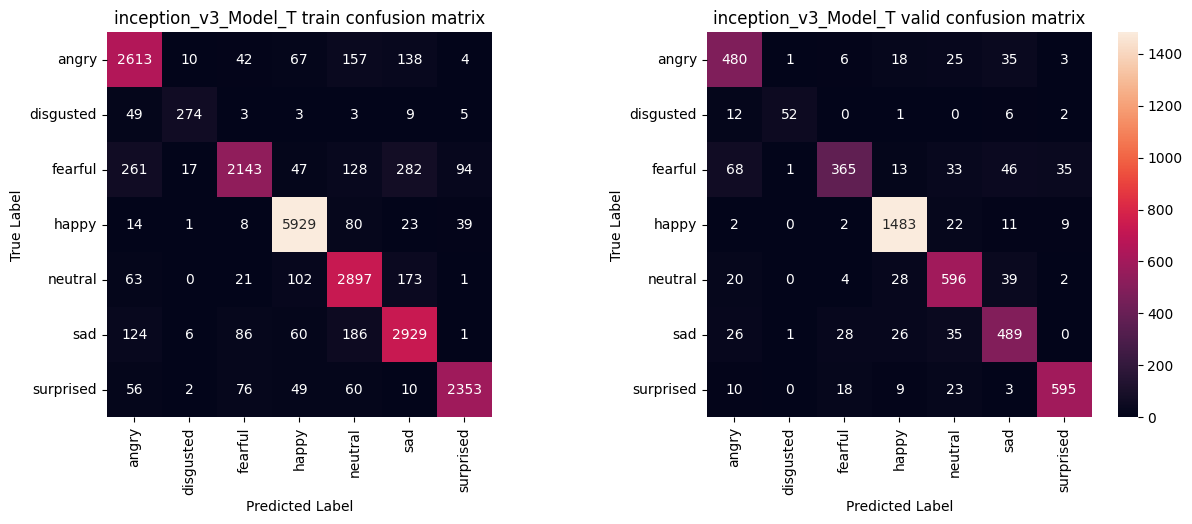

In [49]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T")

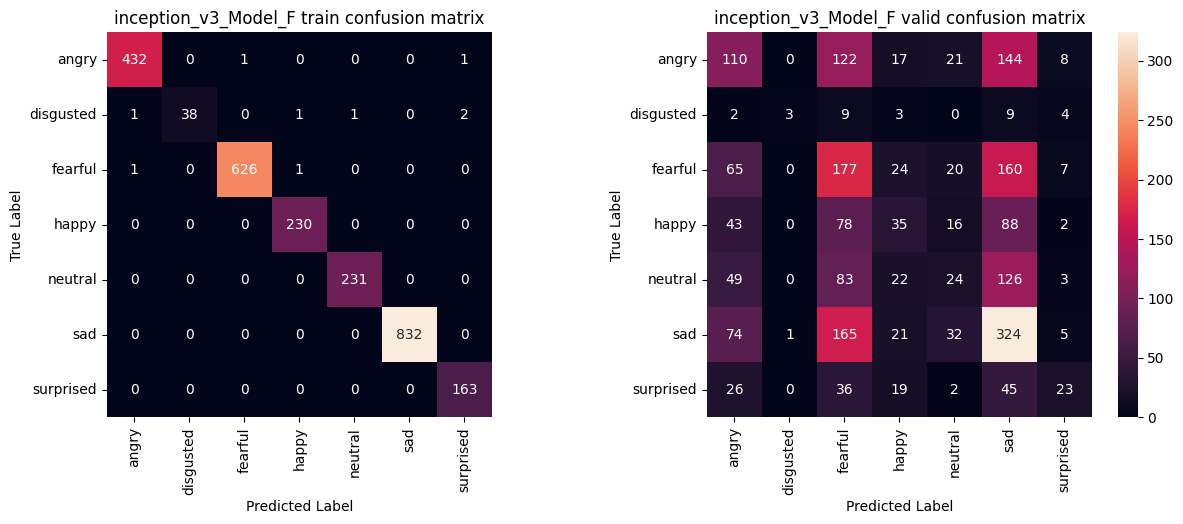

In [50]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F")

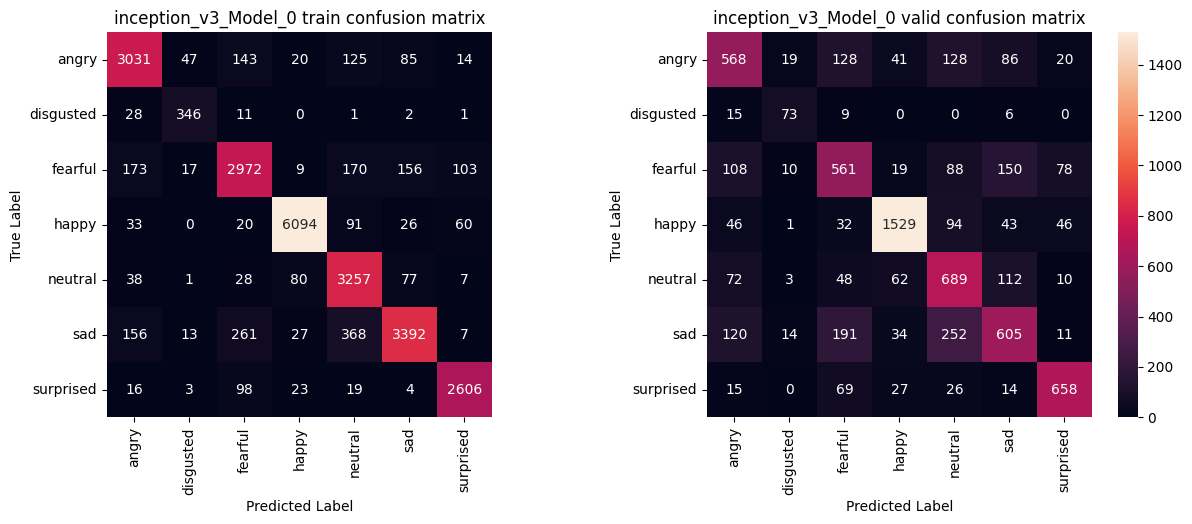

In [51]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0")

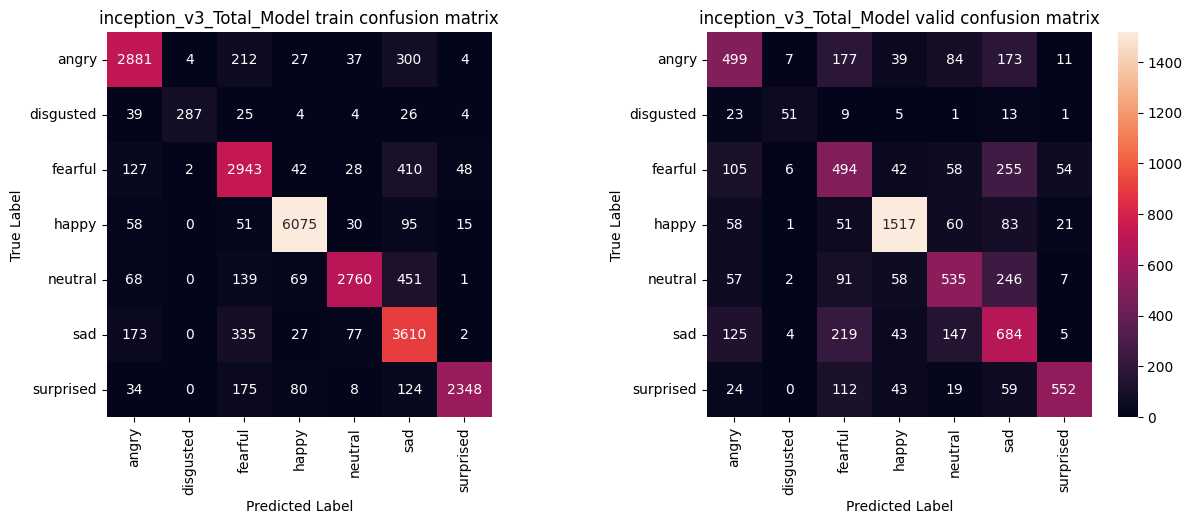

In [52]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model")

In [53]:
# 創建一個空的DataFrame
df = pd.DataFrame(columns=['id','max_0','max_t', 'max_f','model_0_prob','model_t_prob', 'model_f_prob','model_0_pred', 'model_t_pred', 'model_f_pred','true_label','true_choose', 'correct','choose'])

# 遍歷驗證集中的每筆資料，並記錄相關資訊到DataFrame中
for data, target, idx in valid_dl:
    model_0,model_T,model_F=model_0.cpu(),model_T.cpu(),model_F.cpu()
    out = model_0(data)
    out_t = model_T(data)
    out_f = model_F(data)
    
    # 取得模型的預測結果
    _, y_pred = torch.max(out, dim=1)
    _, y_pred_t = torch.max(out_t, dim=1)
    _, y_pred_f = torch.max(out_f, dim=1)
    
    # 取得模型的預測機率
    probs = torch.softmax(out, dim=1)
    probs_t = torch.softmax(out_t, dim=1)
    probs_f = torch.softmax(out_f, dim=1)
    # probs_f=temperature_scaling(probs_f,1.5)

    max_probs, _ = torch.max(probs, dim=1)
    max_probs_t, _ = torch.max(probs_t, dim=1)
    max_probs_f, _ = torch.max(probs_f, dim=1)
    
    
    choose=torch.zeros_like(target)
    choose[(max_probs_t >= max_probs_f)] = 0  # model_t
    choose[(max_probs_t < max_probs_f)] = 1  # model_f

    true_choose=torch.zeros_like(target)
    true_choose[(y_pred==target)] = 0  # model_t
    true_choose[(y_pred!=target)] = 1  # model_f

    # 取得是否預測正確的結果
    correct = torch.zeros_like(target)
    correct[(y_pred_t == target) & (y_pred_f == target)] = 0    # 兩個模型都預測對
    correct[(y_pred_t == target) & (y_pred_f != target)] = 1    # model_T 預測對
    correct[(y_pred_t != target) & (y_pred_f == target)] = 2    # model_F 預測對
    correct[(y_pred_t != target) & (y_pred_f != target)] = 3    # 兩個模型都預測錯誤

    
    # 將資訊添加到DataFrame中
    for i in range(len(idx)):
        data_id = idx[i].item()
        max_0=max_probs[i].item()
        max_t=max_probs_t[i].item()
        max_f=max_probs_f[i].item()
        model_prob = probs[i, target[i]].item()

        model_t_prob = probs_t[i, target[i]].item()
        model_t_pred = y_pred_t[i].item()
        model_f_prob = probs_f[i, target[i]].item()
        model_f_pred = y_pred_f[i].item()
        model_0_pred=y_pred[i].item()
        true_label=target[i].item()
        is_true_choose=true_choose[i].item()
        is_choose=choose[i].item()
        is_correct = correct[i].item()
        df = pd.concat([df, pd.DataFrame({'id': [data_id],'max_0':[max_0],'max_t':[max_t],'max_f':[max_f],'model_0_prob':[model_prob], 'model_t_prob': [model_t_prob], 'model_f_prob': [model_f_prob],'model_0_pred':[model_0_pred], 'model_t_pred': [model_t_pred], 'model_f_pred': [model_f_pred] ,'true_label': [true_label],'true_choose':[is_true_choose], 'correct': [is_correct],'choose': [is_choose]})], ignore_index=True)

df


,id,max_0,max_t,max_f,model_0_prob,model_t_prob,model_f_prob,model_0_pred,model_t_pred,model_f_pred,true_label,true_choose,correct,choose
0,26673,0.859568,0.841769,0.912874,0.859568,0.841769,0.912874,5,5,5,5,0,0,1
1,30154,0.702707,0.564139,0.439572,0.190712,0.412453,0.439572,4,4,5,5,1,2,0
2,26406,0.956478,0.655079,0.993939,0.956478,0.655079,0.000524,5,5,2,5,0,1,1
3,1713,0.917569,0.696195,0.368458,0.020984,0.257592,0.368458,2,2,0,0,1,2,0
4,28638,0.794126,0.911752,0.451415,0.794126,0.911752,0.451415,5,5,5,5,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6925,12022,0.964256,0.538631,0.588593,0.964256,0.538631,0.043215,3,3,5,3,0,1,1
6926,16426,0.573537,0.417397,0.834518,0.385499,0.404292,0.005909,4,4,0,3,1,3,1
6927,5950,0.439464,0.300166,0.924959,0.255354,0.184866,0.069636,5,5,5,2,1,3,1
6928,7535,0.388662,0.565106,0.445168,0.185659,0.132102,0.445168,5,5,2,2,1,2,0


In [54]:
df[(df['true_choose']==0) & (df['choose']==1)]  #實際上應該是要用model_T但被分到用model_F

,id,max_0,max_t,max_f,model_0_prob,model_t_prob,model_f_prob,model_0_pred,model_t_pred,model_f_pred,true_label,true_choose,correct,choose
0,26673,0.859568,0.841769,0.912874,0.859568,0.841769,0.912874,5,5,5,5,0,0,1
2,26406,0.956478,0.655079,0.993939,0.956478,0.655079,0.000524,5,5,2,5,0,1,1
7,25738,0.793210,0.673208,0.863096,0.793210,0.673208,0.062532,5,5,4,5,0,1,1
8,30853,0.793145,0.466045,0.966531,0.793145,0.458052,0.000886,6,2,2,6,0,3,1
12,32687,0.861746,0.675939,0.986877,0.861746,0.675939,0.000402,6,6,5,6,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6910,31719,0.998245,0.630719,0.926761,0.998245,0.630719,0.001394,6,6,5,6,0,1,1
6913,27770,0.613907,0.764699,0.971127,0.613907,0.224667,0.009560,5,2,2,5,0,3,1
6916,6232,0.628800,0.410002,0.890942,0.628800,0.410002,0.009347,2,2,5,2,0,1,1
6917,20783,0.972105,0.982838,0.990411,0.972105,0.982838,0.000425,4,4,5,4,0,1,1


In [55]:
len(df[(df['true_choose']==0) & (df['choose']==1)&(df['model_f_pred']==df['true_label'])] ) #實際上應該是要用model_T但被分到用model_F但是有分類正確

260

In [56]:
df[(df['true_choose']==1) & (df['choose']==0)]  #實際上應該是要用model_F但被分到用model_T

,id,max_0,max_t,max_f,model_0_prob,model_t_prob,model_f_prob,model_0_pred,model_t_pred,model_f_pred,true_label,true_choose,correct,choose
1,30154,0.702707,0.564139,0.439572,0.190712,0.412453,0.439572,4,4,5,5,1,2,0
3,1713,0.917569,0.696195,0.368458,0.020984,0.257592,0.368458,2,2,0,0,1,2,0
9,27864,0.667941,0.774758,0.558568,0.231971,0.172335,0.558568,3,3,5,5,1,2,0
13,7299,0.989245,0.971907,0.857800,0.008814,0.017322,0.047636,0,0,4,2,1,3,0
16,23711,0.481788,0.638163,0.541607,0.348940,0.638163,0.089749,0,4,5,4,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6911,9306,0.529642,0.542165,0.262997,0.373424,0.205264,0.168668,0,0,5,2,1,3,0
6912,31622,0.867316,0.846718,0.542421,0.126665,0.846718,0.015427,2,6,3,6,1,1,0
6921,19029,0.480621,0.797663,0.578097,0.257652,0.797663,0.021516,4,3,0,3,1,1,0
6922,1552,0.585288,0.817304,0.461430,0.160082,0.132489,0.461430,3,3,0,0,1,2,0


In [57]:
len(df[(df['true_choose']==1) & (df['choose']==0)&(df['model_t_pred']==df['true_label'])] ) #實際上應該是要用model_F但被分到用model_T但有分類正確

206

In [58]:
df[(df['model_0_pred']==df['true_label']) & (df['model_t_pred']!=df['true_label']) & (df['model_f_pred']!=df['true_label'])] 

,id,max_0,max_t,max_f,model_0_prob,model_t_prob,model_f_prob,model_0_pred,model_t_pred,model_f_pred,true_label,true_choose,correct,choose
8,30853,0.793145,0.466045,0.966531,0.793145,0.458052,0.000886,6,2,2,6,0,3,1
42,22728,0.524417,0.616688,0.692845,0.524417,0.111030,0.005606,4,5,5,4,0,3,1
69,28719,0.418267,0.377939,0.324766,0.418267,0.281782,0.192499,5,4,2,5,0,3,0
80,19860,0.463209,0.827035,0.441170,0.463209,0.144797,0.001907,4,0,6,4,0,3,0
83,23513,0.920954,0.595438,0.904689,0.920954,0.391562,0.004645,4,0,2,4,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6876,7433,0.639794,0.492746,0.805583,0.639794,0.137243,0.039751,2,3,5,2,0,3,1
6885,18148,0.599218,0.795433,0.716248,0.599218,0.104326,0.022697,3,5,5,3,0,3,0
6895,23396,0.566285,0.718041,0.327215,0.566285,0.163455,0.029271,4,5,2,4,0,3,0
6900,26046,0.848668,0.904992,0.929262,0.848668,0.051563,0.007415,5,3,2,5,0,3,1


In [59]:
with torch.no_grad():
    false_T=0
    false_F=0
    for data,target,idx in valid_dl:

        outputs=[]
        # data,target=data.to(device),target.to(device)
        out=model_0(data)

        softmax = torch.nn.functional.softmax(out, dim=1)
        
        for d,t in zip(data,target):

            out_f=model_F(d.unsqueeze(0))
            out_t=model_T(d.unsqueeze(0))
            
            softmax_F = torch.softmax(out_f, dim=1)
            softmax_T = torch.softmax(out_t, dim=1)


            # temperature1 = 1.5
            # temperature2 = 0.3

            # # 對預測概率進行溫度調整
            # softmax_F = torch.exp(softmax_F / temperature1) / torch.exp(softmax_F / temperature1).sum(dim=1, keepdim=True)
            # softmax_T = torch.exp(softmax_T / temperature2) / torch.exp(softmax_T / temperature2).sum(dim=1, keepdim=True)

            

            # softmax_F=sorted(softmax_F,reverse=True)
            # value_F=softmax_F[0]-softmax_F[1]

            # softmax_T=sorted(softmax_T,reverse=True)
            # value_T=softmax_T[0]-softmax_T[1]
            out=model_0(d.unsqueeze(0))
            _,y_pred_tag=torch.max(out, dim = 1)
            if(softmax_T.max()>softmax_F.max()):
                
                if (t!=y_pred_tag).item():
                    false_T+=1
            else:

                if (t==y_pred_tag).item():
                    false_F+=1

false_T,false_F

In [ ]:
def temperature_scaling(logits, temperature):
    """
    使用溫度調整方法校準模型的預測機率
    
    參數：
        logits：模型的輸出（未經softmax處理的輸出）
        temperature：溫度參數
        
    返回：
        prob：校準後的預測機率
    """
    prob = torch.softmax(logits / temperature, dim=1)
    return prob

In [ ]:
# 使用計算 ECE 的函式
def calculate_ece(model, dataloader, num_bins=10):
    model.eval()
    total_samples = len(dataloader.dataset)
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    bin_confidence = np.zeros(num_bins)
    bin_accuracy = np.zeros(num_bins)
    bin_samples = np.zeros(num_bins)
    ece = 0.0

    with torch.no_grad():
        for images, labels,idx in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            softmax_probs = torch.softmax(outputs, dim=1)
            
            softmax_probs=temperature_scaling(softmax_probs,0.1)
            
            confidences, predictions = torch.max(softmax_probs, dim=1)
            correct_predictions = predictions.eq(labels)

            for i in range(num_bins):
                mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
                
                num_samples = mask.sum().item()
                if num_samples > 0:
                    accuracy = correct_predictions[mask].sum().item() / num_samples
                    confidence = confidences[mask].mean().item()
                    bin_confidence[i] += confidence
                    bin_accuracy[i] += accuracy
                    bin_samples[i] += num_samples

    for i in range(num_bins):
        if bin_samples[i] > 0:
            avg_confidence = bin_confidence[i] / bin_samples[i]
            accuracy = bin_accuracy[i] / bin_samples[i]
            ece += np.abs(accuracy - avg_confidence) * (bin_samples[i] / total_samples)

    return ece


ece = calculate_ece(model_T, train_dl)
print(f"ECE: {ece}")

NameError: name 'temperature_scaling' is not defined

In [ ]:
# 定義一個校準方法來獲得可信度分數
def calibration_curve(model, data_dl):
    model.eval()
    with torch.no_grad():
        confidences = []
        for data, target, _ in data_dl:
            data, target = data.cuda(), target.cuda()
            out = model(data)
            prob = torch.softmax(out, dim=1)
            confidence = torch.max(prob, dim=1).values
            confidences.append(confidence.cpu().numpy())
        
        confidences = np.concatenate(confidences)
        return confidences

# 使用校準方法獲得可信度分數
confidences = calibration_curve(model_0, valid_dl)

# 可信度分數範圍介於 0 和 1 之間，越接近 1 表示模型對於該預測越自信
print(confidences)

[0.46686193 0.9986633  0.997741   ... 0.93761384 0.60622406 0.56270784]


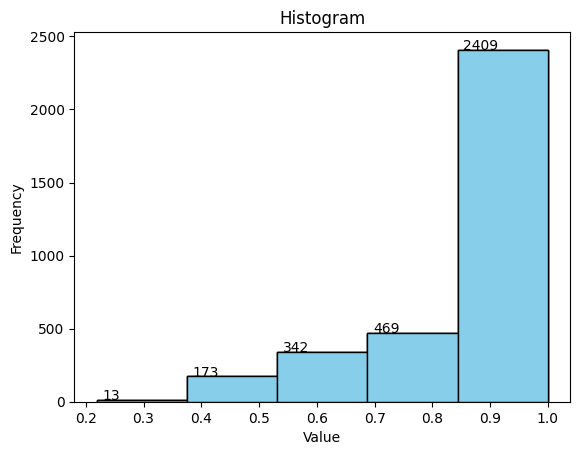

In [ ]:
plot_hist(confidences)